#

<div align=center>
<img src="https://uol.unifor.br/acesso/app/autenticacao/assets/img/logos/icon-unifor.svg" width=45 height=45>

<br><br>
<font size=5 color='black'><strong>MBA Ciência de dados:</strong> Estatística descritiva

<strong>Projeto:</strong> Titanic

<strong>Autoria:</strong> Heitor Teixeira

</div>

## <font color=darkblue> 1 - Imports e declaração de constantes

### <font color=steelblue> 1.1 - Imports

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew
import numpy as np

### <font color=steelblue> 1.2 - Constantes

Declarar constantes em uma unica celula facilita a manutenção de notebooks longos.<br>Alguns benefícios:
1. Melhorar a legibilidade do codigo
2. As constantes podem ser esquema de cores para padronizar sempre as mesmas cores para determinadas classes, paths de arquivos e datasets e etc.
3. posso modifica-las apenas aqui e servir para o codigo inteiro


In [13]:
# dataset do professor
PATH_ELEICOES = "datasets/eleicoes.csv"

# arquivos auxiliares do TSE para enriquecimento
PATH_CANDIDATOS = "datasets/extras/consulta_cand_2014_BRASIL.csv"
PATH_DESPESAS = "datasets/extras/despesas_candidatos_2014_brasil.txt"

PATH_DATASET_ENRIQUECIDO = "datasets/extras/eleicoes_enriquecido.csv"

# paleta de cores para deixar os graficos padronizados
CORES = [
    "#4878D0",
    "#EE854A",
    "#6ACC64",
    "#D65F5F",
    "#956CB4",
]

# tamanho padrao dos graficos
FIGSIZE = (10, 5)

# mapeamento de colunas: dataset original do professor
MAP_COLUMNS_ELEICOES = {
    "State": "Estado",
    "Candidate Number": "Numero Candidato",
    "Money (R$ Reais)": "Gasto",
    "Votes": "Votos",
}

# mapeamento de colunas: prestacao de contas TSE (despesas)
MAP_COLUMNS_DESPESAS = {
    "UF": "Estado",
    "Número candidato": "Numero Candidato",
    "Nome candidato": "Nome",
    "Sigla Partido": "Partido",
    "CPF do candidato": "CPF",
}

# mapeamento de colunas: cadastro oficial de candidatos TSE
MAP_COLUMNS_CANDIDATOS = {
    "SG_UF": "Estado",
    "NR_CANDIDATO": "Numero Candidato",
    "DS_SIT_TOT_TURNO": "Situacao",
    "DS_GENERO": "Genero",
    "DS_GRAU_INSTRUCAO": "Escolaridade",
    "DS_ESTADO_CIVIL": "Estado Civil",
    "DS_COR_RACA": "Raca",
    "DT_NASCIMENTO": "Dt Nascimento",
}

## <font color=darkblue> 2 - Carregamento e Preparação do Dataset

### <font color=steelblue> 2.1 - Carregando o dataset original

**Observações:**
- o dataset original fornecido pelo professor contém dados de candidatos a Deputado Federal nas eleições de 2014
- cada linha representa um candidato, identificado por Estado e Número de Candidato
- as colunas originais foram renomeadas para português via `MAP_COLUMNS_ELEICOES`
- o csv tem espaco nos valores. quando o valor é numerico não tem problema, python reconhece. mas em string é preciso dar o strip().


In [14]:
eleicoes_df = pd.read_csv(PATH_ELEICOES, header=0, names=MAP_COLUMNS_ELEICOES.values())

# strip() na caoluna str
eleicoes_df["Estado"] = eleicoes_df["Estado"].str.strip()

### <font color=steelblue> 2.2 - Feature Engineering

**Observações:**

O enriquecimento dos dados não foi solicitado, mas reflete uma postura natural do cientista de dados: ir além do dataset fornecido para extrair análises com maior contexto e relevância. Dados isolados, sem um objetivo bem definido dizem pouco. Os dados adicionais dão direção e profundidade para a análise. 

- enriqueci o dataset original com dois arquivos públicos do TSE: prestação de contas de despesas e cadastro oficial de candidatos
- os três arquivos são lidos uma única vez e todos os joins são feitos nesta seção, evitando releituras ao longo do notebook
- a chave de join utilizada é `Estado` + `Numero Candidato` em ambos os merges
- de `despesas_candidatos_2014_brasil.txt`: extrai nome, partido, cargo e CPF por candidato (via `drop_duplicates`) e agrega quantidade de notas e total declarado ao TSE (via `groupby`)
- de `consulta_cand_2014_BRASIL.csv`: filtrei apenas candidatos com número de 4 dígitos, padrão exclusivo de Deputado Federal, e extraí gênero, escolaridade, raça, estado civil e resultado eleitoral

#### <font color=slategray> 2.2.1 - Aquisição de dados externos

**Observações:**

carrego dois arquivos auxiliares do TSE para enriquecer o dataset original:

| Dataset | Arquivo | Uso |
|---|---|---|
| `eleicoes.csv` | Dataset original fornecido | Gasto total e votos por candidato |
| Prestação de Contas 2014 | `despesas_candidatos_2014_brasil.txt` | Validação dos valores, nome, partido, cargo e quantidade de notas |
| Cadastro de Candidatos 2014 | `consulta_cand_2014_BRASIL.csv` | Situação eleitoral, gênero, raça, escolaridade, data de nascimento |

**Fonte:** [dadosabertos.tse.jus.br](https://dadosabertos.tse.jus.br), Eleições Gerais 2014, Deputado Federal.

> Os dados referem-se à **prestação de contas final** (após revisão pelo TSE).

In [ ]:
# essa celula é pra rodar só uma vez pra gerar o dataset enriquecido e depois comentar.
"""
despesas_df = pd.read_csv(
    PATH_DESPESAS,
    sep=";",
    encoding="latin1",
    decimal=",",
    usecols=[
        "UF",
        "Número candidato",
        "Nome candidato",
        "Sigla Partido",
        "Cargo",
        "CPF do candidato",
        "Valor despesa",
    ],
    dtype={"CPF do candidato": str},
)

cand_df = pd.read_csv(
    PATH_CANDIDATOS,
    sep=";",
    encoding="latin1",
    usecols=["SG_UF", "NR_CANDIDATO"] + list(MAP_COLUMNS_CANDIDATOS.keys()),
)
"""

'\ndespesas_df = pd.read_csv(\n    PATH_DESPESAS,\n    sep=";",\n    encoding="latin1",\n    decimal=",",\n    usecols=[\n        "UF",\n        "Número candidato",\n        "Nome candidato",\n        "Sigla Partido",\n        "Cargo",\n        "CPF do candidato",\n        "Valor despesa",\n    ],\n    dtype={"CPF do candidato": str},\n)\n\ncand_df = pd.read_csv(\n    PATH_CANDIDATOS,\n    sep=";",\n    encoding="latin1",\n    usecols=["SG_UF", "NR_CANDIDATO"] + list(MAP_COLUMNS_CANDIDATOS.keys()),\n)\n'

#### <font color=slategray> 2.2.2 - Agregações e merges

**Observações:**

- como o arquivo de despesas tem uma linha por nota fiscal, agreguei por candidato antes do join: `Qtd_Notas` (count) e `Total_Despesas_TSE` (sum). qualitativas extraidas via `drop_duplicates`
- o arquivo do TSE contém todos os candidatos das eleições de 2014, nao apenas deputados federais.
- filtrei apenas registros com numero de 4 digitos, padrao exclusivo de deputado federal. candidatos a outros cargos usam 2, 3 ou 5 digitos
- chave de join utilizada em ambos os merges: `Estado` + `Numero Candidato` pois podem existir candidatos com numeros iguais de estados diferentes.

In [ ]:
"""
qtd_notas = (
    despesas_df.groupby(["UF", "Número candidato"])
    .agg(
        Qtd_Notas=("Valor despesa", "count"),
        Total_Despesas_TSE=("Valor despesa", "sum"),
    )
    .reset_index()
    .rename(columns=MAP_COLUMNS_DESPESAS)
)

candidatos_despesas = (
    despesas_df.drop_duplicates(subset=["UF", "Número candidato"])
    .rename(columns=MAP_COLUMNS_DESPESAS)
    .merge(qtd_notas, on=["Estado", "Numero Candidato"], how="left")[
        [
            "Estado",
            "Numero Candidato",
            "Nome",
            "Partido",
            "Cargo",
            "CPF",
            "Qtd_Notas",
            "Total_Despesas_TSE",
        ]
    ]
)

candidatos = (
    cand_df[cand_df["NR_CANDIDATO"].astype(str).str.len() == 4]
    .drop_duplicates(subset=["SG_UF", "NR_CANDIDATO"])
    .rename(columns=MAP_COLUMNS_CANDIDATOS)
)

eleicoes_enriquecido = eleicoes_df.merge(
    candidatos_despesas, on=["Estado", "Numero Candidato"], how="left"
).merge(candidatos, on=["Estado", "Numero Candidato"], how="left")

eleicoes_enriquecido["Qtd_Notas"] = (
    eleicoes_enriquecido["Qtd_Notas"].fillna(0).astype(int)
)

eleicoes_enriquecido.to_csv(PATH_DATASET_ENRIQUECIDO, index=False)
"""

'\nqtd_notas = (\n    despesas_df.groupby(["UF", "Número candidato"])\n    .agg(\n        Qtd_Notas=("Valor despesa", "count"),\n        Total_Despesas_TSE=("Valor despesa", "sum"),\n    )\n    .reset_index()\n    .rename(columns=MAP_COLUMNS_DESPESAS)\n)\n\ncandidatos_despesas = (\n    despesas_df.drop_duplicates(subset=["UF", "Número candidato"])\n    .rename(columns=MAP_COLUMNS_DESPESAS)\n    .merge(qtd_notas, on=["Estado", "Numero Candidato"], how="left")[\n        [\n            "Estado",\n            "Numero Candidato",\n            "Nome",\n            "Partido",\n            "Cargo",\n            "CPF",\n            "Qtd_Notas",\n            "Total_Despesas_TSE",\n        ]\n    ]\n)\n\ncandidatos = (\n    cand_df[cand_df["NR_CANDIDATO"].astype(str).str.len() == 4]\n    .drop_duplicates(subset=["SG_UF", "NR_CANDIDATO"])\n    .rename(columns=MAP_COLUMNS_CANDIDATOS)\n)\n\neleicoes_enriquecido = eleicoes_df.merge(\n    candidatos_despesas, on=["Estado", "Numero Candidato"], how="le

#### <font color=slategray> 2.2.3 - Dataset enriquecido

**Observações:**

- o dataset enriquecido foi gerado uma unica vez e salvo em `eleicoes_enriquecido.csv`. nas proximas execucoes, carrego direto do arquivo salvo sem precisar reler e agregar os arquivos do TSE

In [21]:
eleicoes_enriquecido = pd.read_csv(PATH_DATASET_ENRIQUECIDO)

print(f"Tabela 2.2.3 - Dataset enriquecido ({len(eleicoes_enriquecido)} candidatos)")
display(eleicoes_enriquecido.head(5).set_index("Numero Candidato"))

Tabela 2.2.3 - Dataset enriquecido (6353 candidatos)


,Estado,Gasto,Votos,Nome,Partido,Cargo,CPF,Qtd_Notas,Total_Despesas_TSE,Dt Nascimento,Genero,Escolaridade,Estado Civil,Raca,Situacao
Numero Candidato,,,,,,,,,,,,,,,
1919,AC,35504.34,515,JUAREZ PEDROSA CAVALCANTE,PTN,Deputado Federal,1.333425e+10,30,35504.34,24/02/1961,MASCULINO,ENSINO MÉDIO COMPLETO,DIVORCIADO(A),PARDA,SUPLENTE
1212,AC,397136.76,11397,JOSÉ LUIS SCHAFER,PDT,Deputado Federal,3.142027e+10,223,397136.76,20/06/1960,MASCULINO,SUPERIOR COMPLETO,CASADO(A),BRANCA,SUPLENTE
5012,AC,1580.00,15,ANA PAULA MORAIS DE HOLANDA,PSOL,Deputado Federal,8.214671e+10,3,1580.00,10/11/1985,FEMININO,ENSINO MÉDIO COMPLETO,SOLTEIRO(A),PARDA,NÃO ELEITO
1321,AC,66093.33,1913,ROSELI COSTA,PT,Deputado Federal,3.080045e+10,21,66093.33,04/06/1970,FEMININO,SUPERIOR COMPLETO,CASADO(A),PARDA,SUPLENTE
1144,AC,296327.21,13610,VANDA DENIR MILANI NOGUEIRA,PP,Deputado Federal,7.858185e+10,178,296327.21,17/09/1953,FEMININO,SUPERIOR COMPLETO,CASADO(A),BRANCA,SUPLENTE


### <font color=steelblue> 2.3 - Validação dos dados mesclados

**Observações:**

apos o enriquecimento, o dataset possui duas colunas de gasto: `Gasto` (fornecida pelo professor) e `Total_Despesas_TSE` (calculada a partir da soma das despesas declaradas ao TSE). a validacao e feita em duas frentes:
- completude: todos os candidatos do dataset original estao presentes no TSE?
- consistencia: os valores de `Gasto` e `Total_Despesas_TSE` sao compativeis?

#### <font color=slategray> 2.3.1 - Completude

cruzei todos os candidatos do dataset original com o arquivo de prestacao de contas do TSE. candidatos sem match na coluna `Nome` sao aqueles sem nenhuma nota fiscal registrada. candidatos com `Gasto = 0` sem match sao esperados. candidatos com `Gasto > 0` sem match sao inconsistencias.

In [ ]:
sem_match = eleicoes_enriquecido["Nome"].isna()
sem_match_zero = sem_match & (eleicoes_enriquecido["Gasto"] == 0)
sem_match_valor = sem_match & (eleicoes_enriquecido["Gasto"] > 0)
encontrados = ~sem_match

resumo_completude = pd.DataFrame(
    {
        "Situacao": [
            "Total de candidatos no dataset original",
            "Encontrados nos dados TSE 2014",
            "Nao encontrados com Gasto = R$ 0 (sem despesas declaradas)",
            "Nao encontrados com Gasto > 0 (inconsistencias)",
        ],
        "Quantidade": [
            len(eleicoes_enriquecido),
            encontrados.sum(),
            sem_match_zero.sum(),
            sem_match_valor.sum(),
        ],
    }
)
resumo_completude["% do Total"] = (
    resumo_completude["Quantidade"] / len(eleicoes_enriquecido) * 100
).map("{:.2f}%".format)
resumo_completude["Quantidade"] = resumo_completude["Quantidade"].map("{:,}".format)

print("Tabela 2.3.1 - Completude do cruzamento entre eleicoes.csv e TSE 2014")
display(resumo_completude.set_index("Situacao"))

Tabela 2.3.1 - Completude do cruzamento entre eleicoes.csv e TSE 2014


,Quantidade,% do Total
Situacao,,
Total de candidatos no dataset original,"6,353",100.00%
Encontrados nos dados TSE 2014,"5,392",84.87%
Nao encontrados com Gasto = R$ 0 (sem despesas declaradas),957,15.06%
Nao encontrados com Gasto > 0 (inconsistencias),4,0.06%


**Observações:**
- candidatos com `Gasto = 0` sem match no TSE sao esperados: o TSE so gera registro quando ha ao menos uma nota fiscal
- os poucos casos com `Gasto > 0` sem match representam inconsistencias pontuais e serao detalhados na secao 2.3.2
- apenas 4 candidatos não foram encontrados no dataset do TSE

#### <font color=slategray> 2.3.2 - Consistência dos valores

para os candidatos encontrados em ambos os datasets com `Gasto > 0`, comparei `Gasto` (eleicoes.csv) com `Total_Despesas_TSE` (soma das notas do TSE). classifico as diferencas em tres categorias: match exato, diferenca residual de arredondamento e divergencia real.

In [ ]:
# candidatos com Gasto > 0 sem match no TSE
nao_encontrados = eleicoes_enriquecido[sem_match_valor][
    ["Estado", "Numero Candidato", "Gasto"]
].copy()
nao_encontrados["Total_Despesas_TSE"] = 0.0
nao_encontrados["Diferenca"] = nao_encontrados["Gasto"]

print("Tabela 2.3.2a - Candidatos com Gasto > 0 nao encontrados no TSE")
display(nao_encontrados.reset_index(drop=True))

# consistencia para os candidatos cruzados com Gasto > 0
mask_cruzados = eleicoes_enriquecido["Total_Despesas_TSE"].notna() & (
    eleicoes_enriquecido["Gasto"] > 0
)
comparacao = eleicoes_enriquecido[mask_cruzados].copy()
comparacao["Diferenca"] = (comparacao["Gasto"] - comparacao["Total_Despesas_TSE"]).abs()

mask_match = comparacao["Diferenca"] < 0.01
mask_residual = (comparacao["Diferenca"] >= 0.01) & (comparacao["Diferenca"] < 1)
mask_diverge = comparacao["Diferenca"] >= 1

resumo_consistencia = pd.DataFrame(
    {
        "Situacao": [
            "Match exato (diferenca < R$ 0,01)",
            "Diferenca residual (R$ 0,01 a R$ 1,00)",
            "Divergencia de valor (> R$ 1,00)",
            "Total candidatos cruzados",
        ],
        "Quantidade": [
            mask_match.sum(),
            mask_residual.sum(),
            mask_diverge.sum(),
            len(comparacao),
        ],
    }
)
resumo_consistencia["% do Cruzado"] = (
    resumo_consistencia["Quantidade"] / len(comparacao) * 100
).map("{:.2f}%".format)
resumo_consistencia["Quantidade"] = resumo_consistencia["Quantidade"].map("{:,}".format)

print("Tabela 2.3.2b - Consistencia entre Gasto (eleicoes.csv) e Total_Despesas_TSE")
display(resumo_consistencia.set_index("Situacao"))

print(f"\nDiferenca maxima: R$ {comparacao['Diferenca'].max():,.2f}")
print(f"Diferenca media:  R$ {comparacao['Diferenca'].mean():,.4f}")

Tabela 2.3.2a - Candidatos com Gasto > 0 nao encontrados no TSE


,Estado,Numero Candidato,Gasto,Total_Despesas_TSE,Diferenca
0,GO,3690,600.00,0.0,600.00
1,GO,3134,100.00,0.0,100.00
2,MG,3686,300.00,0.0,300.00
3,SP,1303,118209.44,0.0,118209.44


Tabela 2.3.2b - Consistencia entre Gasto (eleicoes.csv) e Total_Despesas_TSE


,Quantidade,% do Cruzado
Situacao,,
"Match exato (diferenca < R$ 0,01)","5,054",95.02%
"Diferenca residual (R$ 0,01 a R$ 1,00)",1,0.02%
"Divergencia de valor (> R$ 1,00)",264,4.96%
Total candidatos cruzados,"5,319",100.00%



Diferenca maxima: R$ 966,926.11
Diferenca media:  R$ 585.0874


**Observações:**
- a soma das despesas do TSE reproduz os valores do dataset original na grande maioria dos casos
- diferencas residuais (< R$ 1,00) sao atribuiveis a arredondamento de ponto flutuante
- `eleicoes.csv` e derivado do campo `Valor despesa` da prestacao de contas do TSE
- divergencias acima de R$ 1,00 sugerem que `eleicoes.csv` foi compilado a partir de uma versao anterior da prestacao de contas, anterior a revisao final pelo TSE
- a diferenca de versao nao compromete a analise: `Gasto` permanece como a medida oficial do gasto declarado

#### <font color=slategray> 2.3.3 - Análise comparativa

**Observações:**

Removi todos os dados de candidatos com `Gasto = 0`. Por que?
- as análises são de gastos, um candidato que não gastou durante toda a eleição provavelmente é alguém que desistiu de sua campanha
- o número de candidatos que não gastaram é algo relavante dentro de todo dataset `~15%`. esse número é razoável e pode afetar métricas como média e mediana.
- `TODOS` os candidatos eleitos, de acordo com o TSE, gastaram alguma coisa. Portanto, não faz sentido em análises comparativas deixa-los no dataset.

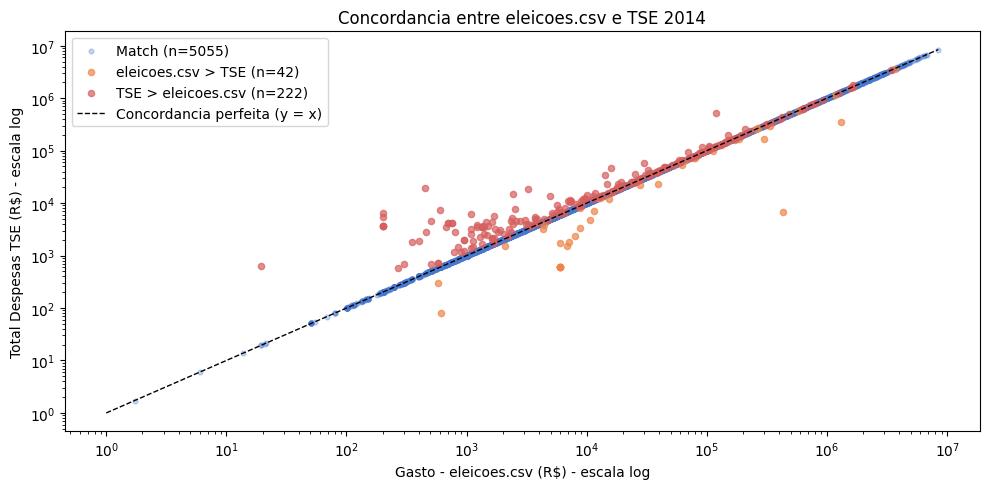

In [ ]:
mask_match_plot = comparacao["Diferenca"] < 1
mask_div_el = (comparacao["Diferenca"] >= 1) & (
    comparacao["Gasto"] > comparacao["Total_Despesas_TSE"]
)
mask_div_ts = (comparacao["Diferenca"] >= 1) & (
    comparacao["Total_Despesas_TSE"] > comparacao["Gasto"]
)

fig, ax = plt.subplots(figsize=FIGSIZE)

ax.scatter(
    comparacao.loc[mask_match_plot, "Gasto"] + 1,
    comparacao.loc[mask_match_plot, "Total_Despesas_TSE"] + 1,
    color=CORES[0],
    alpha=0.3,
    s=12,
    label=f"Match (n={mask_match_plot.sum()})",
)
ax.scatter(
    comparacao.loc[mask_div_el, "Gasto"] + 1,
    comparacao.loc[mask_div_el, "Total_Despesas_TSE"] + 1,
    color=CORES[1],
    alpha=0.7,
    s=20,
    label=f"eleicoes.csv > TSE (n={mask_div_el.sum()})",
)
ax.scatter(
    comparacao.loc[mask_div_ts, "Gasto"] + 1,
    comparacao.loc[mask_div_ts, "Total_Despesas_TSE"] + 1,
    color=CORES[3],
    alpha=0.7,
    s=20,
    label=f"TSE > eleicoes.csv (n={mask_div_ts.sum()})",
)

lim = max(comparacao["Gasto"].max(), comparacao["Total_Despesas_TSE"].max()) + 1
ax.plot([1, lim], [1, lim], "k--", linewidth=1, label="Concordancia perfeita (y = x)")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Gasto - eleicoes.csv (R$) - escala log")
ax.set_ylabel("Total Despesas TSE (R$) - escala log")
ax.set_title("Concordancia entre eleicoes.csv e TSE 2014")
ax.legend()
plt.tight_layout()
plt.savefig("assets/validacao_gasto_tse.png")
plt.show()

**Observações:**
- pontos sobre a diagonal: valores identicos nas duas fontes
- pontos abaixo da diagonal: `eleicoes.csv` registra mais que o TSE
- pontos acima da diagonal: TSE registra mais que `eleicoes.csv`
- a concentracao de pontos sobre a diagonal confirma a consistencia dos dados
- as divergencias sao pontuais e nao comprometem a analise